In [5]:
# %% [markdown]
# # Bayesian Network Training with Explainability (Binary Dataset)
# 
# This notebook builds and trains a Bayesian network for disease prediction using a binary-formatted dataset. 
# It also includes an interactive terminal interface and an explainability module to understand *why* a prediction was made.
# 
# ## Dataset Format
# - **prognosis**: Disease name
# - **131 symptom columns**: Binary (0=absent, 1=present)
# 
# ## Network Structure
# We use a **Naive Bayes structure**:
# - Disease (prognosis) is the parent node
# - All symptoms are children of the disease node
# - Assumes conditional independence of symptoms given the disease

# %% [markdown]
# ## 1. Import Libraries

# %%
%pip install google-generativeai

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from sklearn.metrics import accuracy_score
from google import genai
import pickle
import warnings
import os
import json
import google.generativeai as genai

warnings.filterwarnings('ignore')
print("✓ Libraries imported successfully!")

# %% [markdown]
# ## 2. Load Binary Dataset

# %%
# Load binary datasets (Adjust paths if running from a different directory)
df_train = pd.read_csv('../data/Training_binary.csv')
df_test = pd.read_csv('../data/Testing_binary.csv')

print(f"Training data: {df_train.shape}")
print(f"Testing data: {df_test.shape}")

# Get symptom columns (all columns except 'prognosis')
symptom_cols = [col for col in df_train.columns if col != 'prognosis']
print(f"\nSymptoms: {len(symptom_cols)}")
print(f"Diseases: {df_train['prognosis'].nunique()}")

# %% [markdown]
# ## 3. Build Bayesian Network Structure

# %%
# Create Naive Bayes structure: prognosis -> All Symptoms
edges = [('prognosis', symptom) for symptom in symptom_cols]

print(f"Creating Bayesian Network with {len(edges)} edges...")
model = DiscreteBayesianNetwork(edges)

print("\n✓ Bayesian Network structure created!")
print(f"  Nodes: {len(model.nodes())}")
print(f"  Edges: {len(model.edges())}")

# %% [markdown]
# ## 4. Visualize Network Structure 



Note: you may need to restart the kernel to use updated packages.
✓ Libraries imported successfully!
Training data: (4428, 132)
Testing data: (492, 132)

Symptoms: 131
Diseases: 41
Creating Bayesian Network with 131 edges...

✓ Bayesian Network structure created!
  Nodes: 132
  Edges: 131


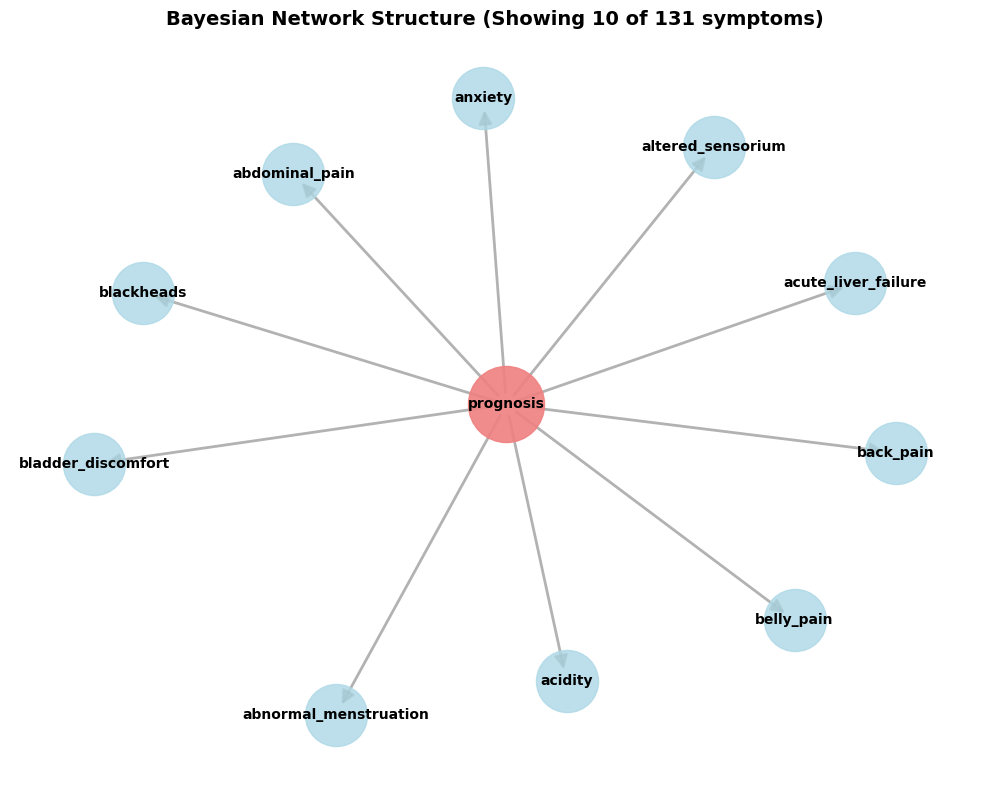

In [6]:
# %%
import networkx as nx

# Create a simplified network for visualization (first 10 symptoms only)
sample_symptoms = symptom_cols[:10]
sample_edges = [('prognosis', symptom) for symptom in sample_symptoms]

G = nx.DiGraph()
G.add_edges_from(sample_edges)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=2, iterations=50)

nx.draw_networkx_nodes(G, pos, nodelist=['prognosis'], node_color='lightcoral', node_size=3000, alpha=0.9)
nx.draw_networkx_nodes(G, pos, nodelist=sample_symptoms, node_color='lightblue', node_size=2000, alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20, width=2, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title(f"Bayesian Network Structure (Showing 10 of {len(symptom_cols)} symptoms)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. Learn Parameters (CPTs)

# %%


In [7]:
print("Preparing data and learning Conditional Probability Tables (CPTs)...")

df_train_prepared = df_train.copy()
df_test_prepared = df_test.copy()

df_train_prepared['prognosis'] = df_train_prepared['prognosis'].astype('category')
df_test_prepared['prognosis'] = df_test_prepared['prognosis'].astype('category')

for col in symptom_cols:
    df_train_prepared[col] = df_train_prepared[col].astype(int)
    df_test_prepared[col] = df_test_prepared[col].astype(int)

model.fit(df_train_prepared, estimator=MaximumLikelihoodEstimator)
print("✓ Training complete!")

# %% [markdown]
# ## 6. Create Inference Engine

# %%


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'prognosis': 'C', 'abdominal_pain': 'N', 'abnormal_menstruation': 'N', 'acidity': 'N', 'acute_liver_failure': 'N', 'altered_sensorium': 'N', 'anxiety': 'N', 'back_pain': 'N', 'belly_pain': 'N', 'blackheads': 'N', 'bladder_discomfort': 'N', 'blister': 'N', 'blood_in_sputum': 'N', 'bloody_stool': 'N', 'blurred_and_distorted_vision': 'N', 'breathlessness': 'N', 'brittle_nails': 'N', 'bruising': 'N', 'burning_micturition': 'N', 'chest_pain': 'N', 'chills': 'N', 'cold_hands_and_feets': 'N', 'coma': 'N', 'congestion': 'N', 'constipation': 'N', 'continuous_feel_of_urine': 'N', 'continuous_sneezing': 'N', 'cough': 'N', 'cramps': 'N', 'dark_urine': 'N', 'dehydration': 'N', 'depression': 'N', 'diarrhoea': 'N', 'dischromic _patches': 'N', 'distention_of_abdomen': 'N', 'dizziness': 'N', 'drying_and_tingling_lips': 'N', 'enlarged_thyroid': 'N', 'excessive_hunger': 'N', 'extra_marital_contacts':

Preparing data and learning Conditional Probability Tables (CPTs)...
✓ Training complete!


In [8]:
inference = VariableElimination(model)
print("✓ Inference engine created (Variable Elimination)!")


✓ Inference engine created (Variable Elimination)!


In [9]:
# This function breaks down why a specific prediction was made by showing the conditional probability 
# of each provided symptom given the predicted disease: $P(Symptom=1 | Disease)$.

# %%
def explain_prediction(symptoms_dict, predicted_disease):
    """
    Explains the prediction by extracting the CPT values for the provided symptoms
    given the predicted disease.
    """
    print(f"\n--- Explanation for diagnosing: {predicted_disease} ---")
    
    # Get the prior probability of the disease P(Disease)
    disease_cpd = model.get_cpds('prognosis')
    disease_states = list(disease_cpd.state_names['prognosis'])
    if predicted_disease in disease_states:
        disease_idx = disease_states.index(predicted_disease)
        prior_prob = disease_cpd.values[disease_idx]
        print(f"Base probability (Prior) of {predicted_disease} in dataset: {prior_prob*100:.2f}%")
    
    print("\nHow your symptoms contributed (Conditional Probabilities):")
    print(f"If a patient has {predicted_disease}, the probability they exhibit these symptoms is:")
    
    contributions = []
    for symptom in symptoms_dict.keys():
        if symptoms_dict[symptom] == 1:
            cpd = model.get_cpds(symptom)
            # cpd.values shape is usually (2, num_diseases) where row 1 is symptom=1
            prob_symptom_given_disease = cpd.values[1, disease_idx]
            contributions.append((symptom, prob_symptom_given_disease))
    
    # Sort by strongest indicator
    contributions.sort(key=lambda x: x[1], reverse=True)
    
    for sym, prob in contributions:
        print(f"  - {sym.replace('_', ' ').title()}: {prob*100:.2f}%")
        
    print("--------------------------------------------------\n")

In [13]:

# %% [markdown]
# ## 8. Dynamic Symptom Elicitation via Gemini API

# %%
import json
import os
import getpass
import google.generativeai as genai

# Try to get the key from the environment first
api_key = os.getenv("GEMINI_API_KEY")

# If it's not found, prompt the user to paste it directly!
if not api_key:
    print("⚠️ GEMINI_API_KEY environment variable not found.")
    print("Get your free API key at: https://aistudio.google.com/app/apikey")
    # getpass hides your key as you type/paste it for security
    api_key = getpass.getpass("Please paste your Gemini API Key here: ")

if not api_key:
    raise ValueError("❌ An API key is required. Please restart the cell and provide a key.")

try:
    # Configure the API
    genai.configure(api_key=api_key)
    
    # Initialize the model (This fixes the 'gemini_model is not defined' error)
    gemini_model = genai.GenerativeModel('gemini-2.5-flash-lite')
    
    # Test the connection quickly
    gemini_model.generate_content("Hello") 
    print("✓ Gemini API initialized and connected successfully.")
    
except Exception as e:
    print(f"⚠️ Error initializing Gemini API: {e}")
    print("Please check that your API key is correct.")

def parse_symptoms_with_llm(user_text, symptom_cols):
    """
    Uses Gemini to extract symptoms from natural language and map them 
    strictly to the database column names.
    """
    # Defensive check
    if 'gemini_model' not in globals():
        print("Error: Model not initialized.")
        return []
        
    prompt = f"""
    You are a medical data parser. 
    The user said: "{user_text}"
    
    Here is the exact list of valid symptom variables in our database:
    {', '.join(symptom_cols)}
    
    Extract the symptoms the user is describing and map them strictly to the exact variable names above.
    Return ONLY a valid JSON list of strings representing the matched variables. 
    If no symptoms match, return an empty list []. Do not include markdown formatting or any other text.
    """
    
    try:
        response = gemini_model.generate_content(prompt)
        
        # Clean up the response to ensure it's just the JSON array
        cleaned_text = response.text.replace('```json', '').replace('```', '').strip()
        matched_symptoms = json.loads(cleaned_text)
        
        # Verify they actually exist in our columns to prevent KeyError
        valid_symptoms = [sym for sym in matched_symptoms if sym in symptom_cols]
        return valid_symptoms
    except Exception as e:
        print(f"Error parsing symptoms: {e}")
        return []

def generate_follow_up_question(top_predictions, current_symptoms):
    """
    Uses Gemini to look at the top predicted diseases and ask the user 
    if they have specific symptoms related to them to narrow it down.
    """
    if 'gemini_model' not in globals():
        return "Are you experiencing any other symptoms?"
        
    top_disease_names = [d[0] for d in top_predictions]
    
    prompt = f"""
    You are an empathetic medical assistant chatbot. 
    The patient has currently reported these symptoms: {', '.join(current_symptoms)}.
    
    Based on our Bayesian Network, the top suspected diseases are: {', '.join(top_disease_names)}.
    
    Ask a brief, conversational follow-up question inquiring if the patient is experiencing 
    any other specific symptoms related to these suspected diseases to help us narrow it down. 
    Do not list the diseases to the patient, just ask about the symptoms. Keep it to one short sentence.
    """
    
    try:
        response = gemini_model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return "Are you experiencing any other symptoms?"

# %% [markdown]
# ## 9. Interactive Terminal Interface

# %%
def interactive_diagnosis_session():
    """Interactive loop combining Bayesian inference with LLM dynamic elicitation."""
    print("="*60)
    print("🤖 GEMINI-POWERED BAYESIAN DIAGNOSIS ASSISTANT")
    print("="*60)
    print("Describe how you're feeling in plain English.")
    print("Type 'quit', 'exit', or 'done' to stop and get your final report.")
    
    collected_symptoms = {}
    
    user_input = input("\n🩺 How can I help you today? \n> ")
    
    while True:
        if user_input.lower().strip() in ['quit', 'exit', 'done']:
            print("\nGenerating final diagnostic report...")
            break
            
        if not user_input.strip():
            user_input = input("> ")
            continue
            
        print("⚙️ Analyzing your response...")
        new_symptoms = parse_symptoms_with_llm(user_input, symptom_cols)
        
        for sym in new_symptoms:
            collected_symptoms[sym] = 1
            
        if not collected_symptoms:
            print("❌ I couldn't quite map that to specific medical symptoms.")
            user_input = input("Could you describe your symptoms differently? \n> ")
            continue
            
        print(f"📋 Currently tracked symptoms: {', '.join(collected_symptoms.keys()).replace('_', ' ')}")
        
        try:
            result = inference.query(variables=['prognosis'], evidence=collected_symptoms)
            probs = result.values
            diseases = result.state_names['prognosis']
            
            predictions = sorted(zip(diseases, probs), key=lambda x: x[1], reverse=True)[:3]
            
            print("\n📊 CURRENT TOP PREDICTIONS:")
            for i, (disease, prob) in enumerate(predictions, 1):
                print(f"  {i}. {disease:30s} {prob*100:6.2f}%")
                
            top_prob = predictions[0][1]
            
            if top_prob > 0.85:
                print(f"\n✅ High confidence reached for {predictions[0][0]}!")
                explain_prediction(collected_symptoms, predictions[0][0])
                break
            else:
                follow_up = generate_follow_up_question(predictions, list(collected_symptoms.keys()))
                user_input = input(f"\n🤖 {follow_up} \n> ")
                
        except Exception as e:
            print(f"❌ Error during prediction: {e}")
            print("This usually happens if conflicting impossible evidence is provided.")
            break

# Run the interactive terminal 
interactive_diagnosis_session()

⚠️ GEMINI_API_KEY environment variable not found.
Get your free API key at: https://aistudio.google.com/app/apikey
✓ Gemini API initialized and connected successfully.
🤖 GEMINI-POWERED BAYESIAN DIAGNOSIS ASSISTANT
Describe how you're feeling in plain English.
Type 'quit', 'exit', or 'done' to stop and get your final report.
⚙️ Analyzing your response...
📋 Currently tracked symptoms: fatigue

📊 CURRENT TOP PREDICTIONS:
  1. Typhoid                          6.19%
  2. Common Cold                      5.96%
  3. Dengue                           5.96%
⚙️ Analyzing your response...
📋 Currently tracked symptoms: fatigue

📊 CURRENT TOP PREDICTIONS:
  1. Typhoid                          6.19%
  2. Common Cold                      5.96%
  3. Dengue                           5.96%
⚙️ Analyzing your response...
Error parsing symptoms: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/

KeyboardInterrupt: Interrupted by user